# Домашнее задание 3

В рамках наших семинаров мы начали разбирать основы использования продвинутой визуализации при работе с алгоритмами машинного обучения. Сегодня попробуем на практике закрепить полученные знания.

Будем использовать датасет для работы с классификацией. Мы продолжаем работать в том же агрохолдинге, где работали с ирисами. Теперь нам дали новую задачу, которая концептуально является похожей — у нас в руках датасет о качестве яблок.

Яблоки бывают хорошие и плохие, но чтобы разобраться с каждым яблоком при большом урожае, придется потратить много времени. Поэтому заказчики и предложили разработать алгоритм классификации яблок на хорошие и плохие. Для того чтобы объяснить неспециалистам принципы работы нашей классификации, нужно создать большое количество визуализаций.

**NB**
Помните, что каждую визуализацию нужно снабдить названием, подписями к осям, легендой (там, где это нужно), а также другими аттрибутами графика, которые кажутся вам важными.

In [42]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
apples = pd.read_csv('https://raw.githubusercontent.com/ElijahSum/mipt_visualization/master/week_03_visualization/apple_quality.csv')
apples.head()

,A_id,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity,Quality
0,0.0,-3.970049,-2.512336,5.346330,-1.012009,1.844900,0.329840,-0.491590483,good
1,1.0,-1.195217,-2.839257,3.664059,1.588232,0.853286,0.867530,-0.722809367,good
2,2.0,-0.292024,-1.351282,-1.738429,-0.342616,2.838636,-0.038033,2.621636473,bad
3,3.0,-0.657196,-2.271627,1.324874,-0.097875,3.637970,-3.413761,0.790723217,good
4,4.0,1.364217,-1.296612,-0.384658,-0.553006,3.030874,-1.303849,0.501984036,good


In [44]:
print(apples.info())
print('-'*50)
print(apples.isna().sum())

apples = apples.dropna()
print('-'*50)

print(apples.isna().sum().sum())
print('-'*50)

apples['Acidity'] = pd.to_numeric(apples['Acidity'])
apples.drop('A_id', axis=1, inplace=True)
apples.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4001 entries, 0 to 4000
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   A_id         4000 non-null   float64
 1   Size         4000 non-null   float64
 2   Weight       4000 non-null   float64
 3   Sweetness    4000 non-null   float64
 4   Crunchiness  4000 non-null   float64
 5   Juiciness    4000 non-null   float64
 6   Ripeness     4000 non-null   float64
 7   Acidity      4001 non-null   object 
 8   Quality      4000 non-null   object 
dtypes: float64(7), object(2)
memory usage: 281.4+ KB
None
--------------------------------------------------
A_id           1
Size           1
Weight         1
Sweetness      1
Crunchiness    1
Juiciness      1
Ripeness       1
Acidity        0
Quality        1
dtype: int64
--------------------------------------------------
0
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Index: 4000 en

In [45]:
apples.describe()

,Size,Weight,Sweetness,Crunchiness,Juiciness,Ripeness,Acidity
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,-0.503015,-0.989547,-0.470479,0.985478,0.512118,0.498277,0.076877
std,1.928059,1.602507,1.943441,1.402757,1.930286,1.874427,2.110270
min,-7.151703,-7.149848,-6.894485,-6.055058,-5.961897,-5.864599,-7.010538
25%,-1.816765,-2.011770,-1.738425,0.062764,-0.801286,-0.771677,-1.377424
50%,-0.513703,-0.984736,-0.504758,0.998249,0.534219,0.503445,0.022609
75%,0.805526,0.030976,0.801922,1.894234,1.835976,1.766212,1.510493
max,6.406367,5.790714,6.374916,7.619852,7.364403,7.237837,7.404736


## Задание 1. Сравнение качества работы kNN при разных параметрах k (7 баллов)

На лекциях и семинарах мы разбирали возможности для применения стандартных библиотек при работе с алгоритмом kNN. Мы также обращали внимание, что существует большое количество кастомных библиотек для создания более тонкой и кастомной визуализации. Одна из таких библиотек — библиотека `mlxtend.plotting`, позволяющая создавать [удобные визуализации](https://rasbt.github.io/mlxtend/) работы алгоритмов машинного обучения. В этой библиотеке есть функция `plot_decision_regions`, позволяющая создавать визуализации для алгоритмов классификации.



**Задание 1.1**

Напишите функцию, которая будет:
1. Отбирать все числовые признаки в датасете.
2. Перебирать все сочетания по два признака (без повторений) и запускать для каждой пары признаков алгоритм kNN (с k = 10). Для каждой итерации необходимо считать Accuracy. Зависимая переменная $y$ указывается отдельно при подаче в функцию (смотрите прототип ниже).
3. Возвращает названия двух признаков, которые дали наибольший `accuracy score`. В случае если accuracy score совпадают для двух или нескольких пар, верните первую пару, которую вы нашли.

Прототип может выглядеть примерно так:


In [46]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

from itertools import combinations

In [47]:
def knn_two_features(df, y):
    '''
    df - датасет, который мы подаем для перебора алгоритмов
    y - зависимая переменная (класс признаков), который мы хотим предсказать
    '''
    y_values = df[y]

    feature_names = df.select_dtypes(include=['number']).columns.tolist()
    if y in feature_names:
        feature_names.remove(y)

    max_acc = 0
    first_feature = ''
    second_feature = ''

    for pair in combinations(feature_names, 2):
        X = df[list(pair)]

        knn = KNeighborsClassifier(n_neighbors=10)

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y_values,
            test_size=0.2,
            stratify=y_values,
            random_state=42
        )

        knn.fit(X_train, y_train)
        y_pred = knn.predict(X_test)

        acc = accuracy_score(y_test, y_pred)

        if acc > max_acc:
            max_acc = acc
            first_feature = pair[0]
            second_feature = pair[1]

    return [first_feature, second_feature]

In [48]:
knn_two_features(apples, 'Quality')

['Sweetness', 'Ripeness']

**Задание 1.2**

Вы получили два признака, которые вместе дают наибольший accuracy score. Теперь самое время попробовать покрутить эти признаки, по ходу изменяя параметр `k`.
С помощью `plot_decision_regions` библиотеки `mlxtend.plotting` постройте поле 3х3 из визуализаций результатов работы алгоритма kNN с разными параметрами `k`.

Параметры `k` можно взять следующие: 1, 2, 5, 10, 15, 20, 30, 40, 50.

Больше о том, как работать с этой функцией, можно почитать [по ссылке](https://rasbt.github.io/mlxtend/user_guide/plotting/plot_decision_regions/).
Там же вы найдете информацию, как создать поле размером 3х3 для построения графиков.

In [49]:
apples['Quality'].unique()

array(['good', 'bad'], dtype=object)

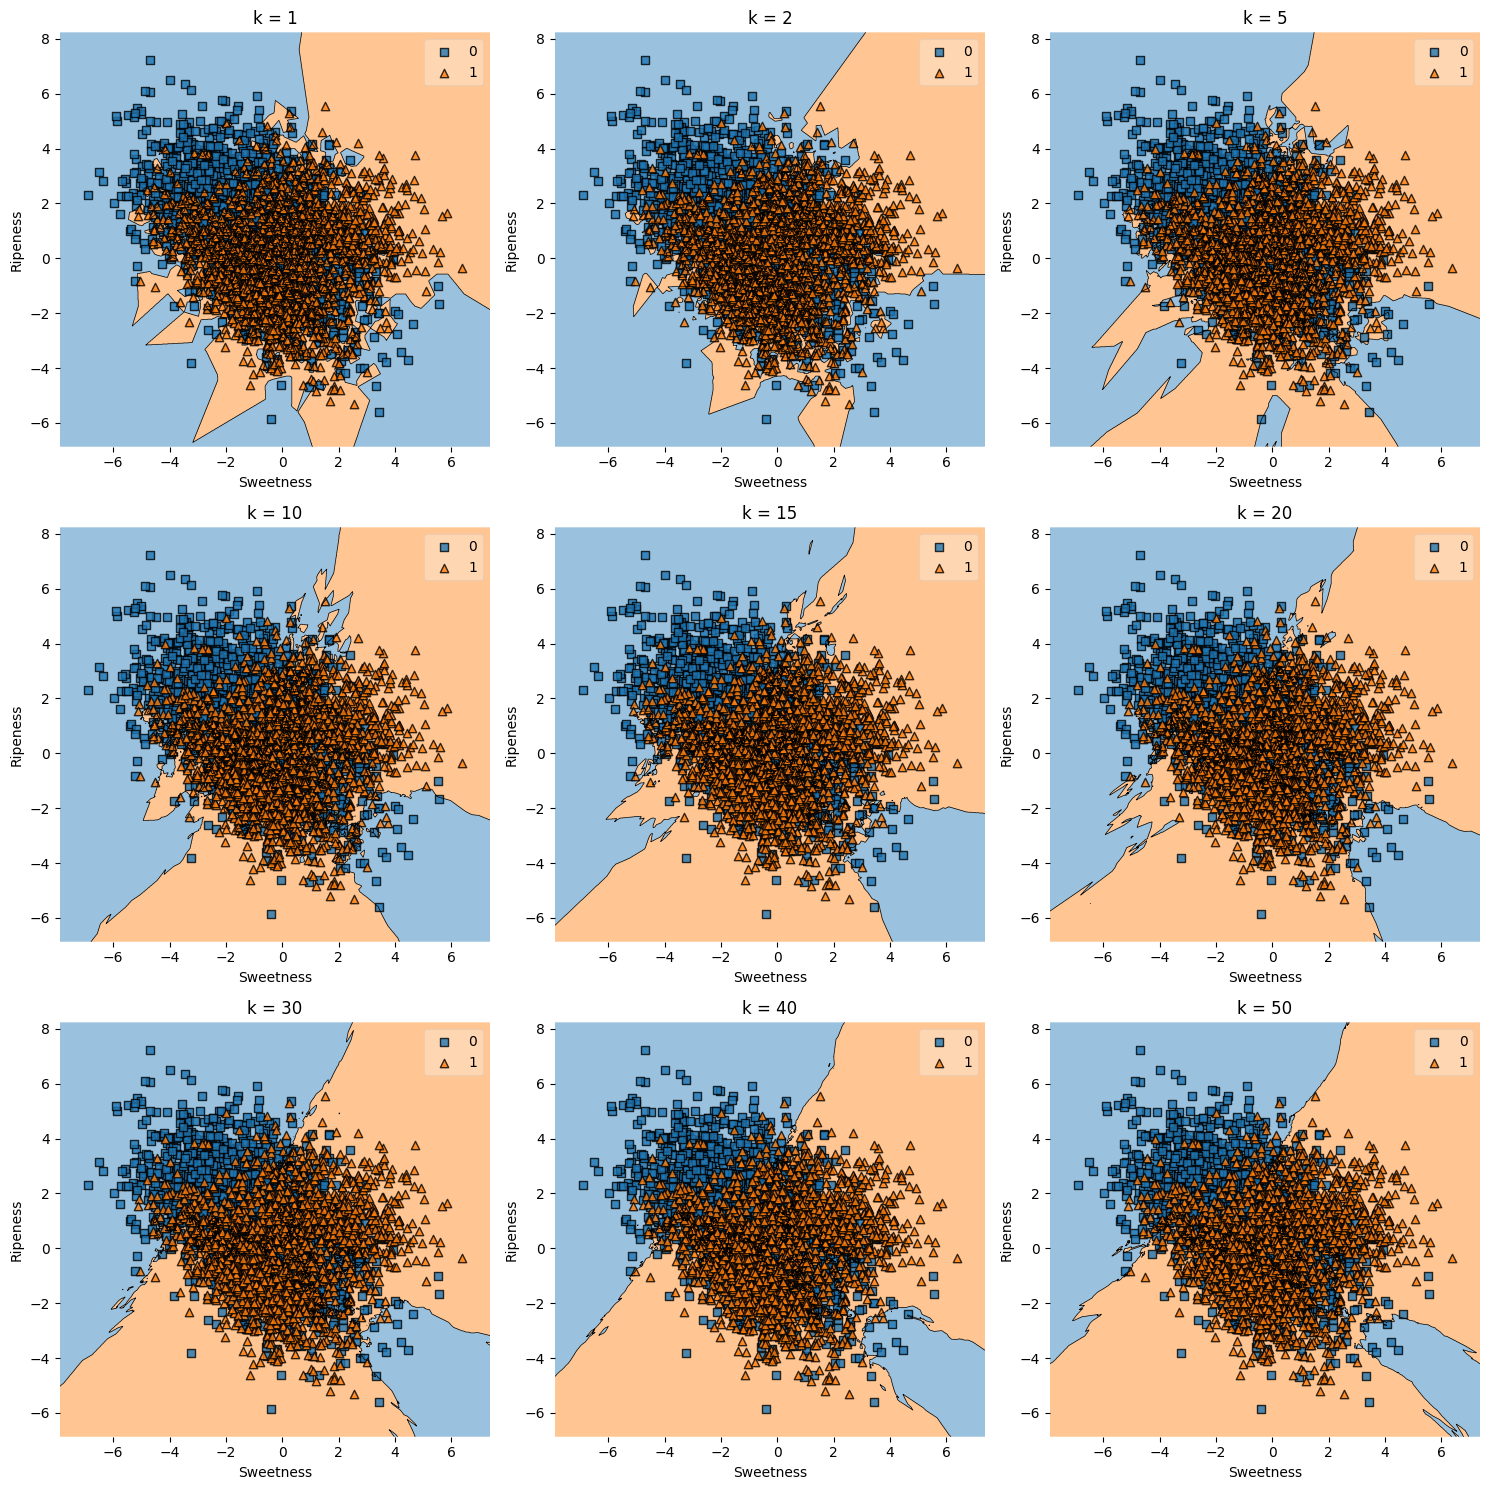

In [50]:
from matplotlib import axes
from mlxtend.plotting import plot_decision_regions

two_features = knn_two_features(apples, 'Quality')

X = apples[two_features].to_numpy()
y = apples['Quality'].map({'bad':0, 'good':1}).to_numpy()

k_values = [1, 2, 5, 10, 15, 20, 30, 40, 50]

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.ravel()

for i, n in enumerate(k_values):

    knn = KNeighborsClassifier(n_neighbors=n)
    knn.fit(X, y)

    plot_decision_regions(X, y, clf=knn, ax=axes[i])

    axes[i].set_title(f'k = {n}')
    axes[i].set_xlabel(two_features[0])
    axes[i].set_ylabel(two_features[1])

plt.tight_layout()
plt.show()

**Задание 1.3**

Удобство функции `plot_decision_regions` состоит в том, что ее можно использовать для визуализации разных алгоритмов классификации.

Выберите 2 параметра, которые кажутся интуитивно наиболее важными, если вы хотите оценить качество яблок. Возьмите эти два признака и, используя их, постройте алгоритм решающего дерева.

Также постройте решающее дерево для признаков, которые были отобраны в пункте 1.1.


Создайте поле 1х2 и визуализируйте полученные результаты. Каждый график озаглавьте.

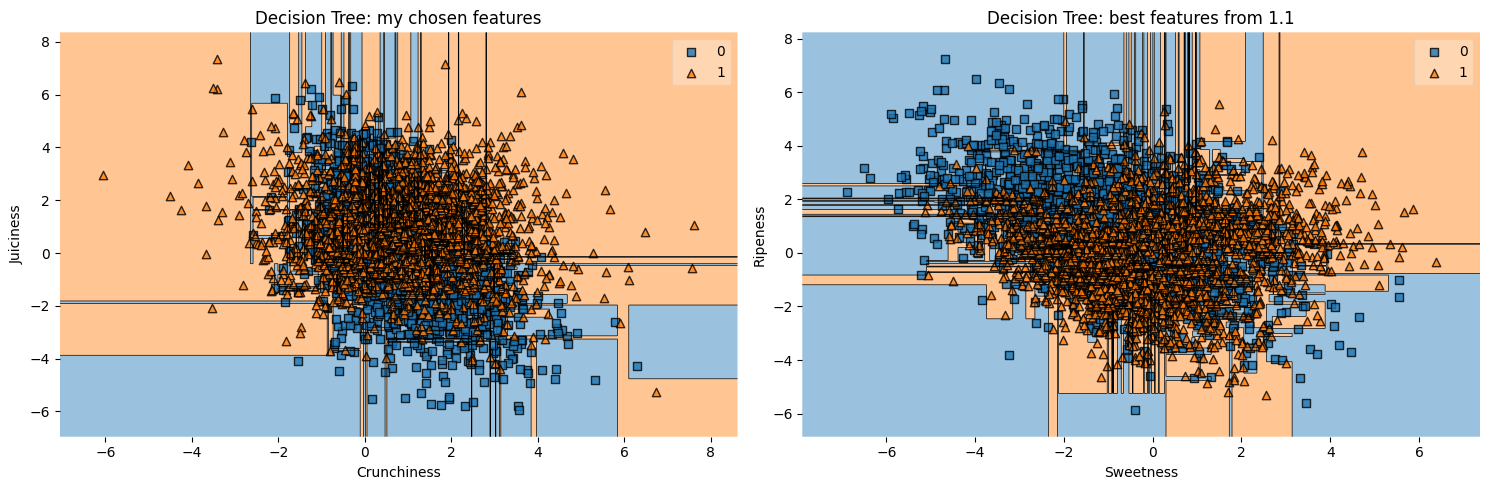

In [51]:
from sklearn.tree import DecisionTreeClassifier

my_two_features = ['Crunchiness', 'Juiciness']
best_two_features = knn_two_features(apples, 'Quality')

X_my = apples[my_two_features].to_numpy()
X_best = apples[best_two_features].to_numpy()
y = apples['Quality'].map({'bad':0, 'good':1}).to_numpy()

d_tree_my = DecisionTreeClassifier(random_state=42)
d_tree_best = DecisionTreeClassifier(random_state=42)

d_tree_my.fit(X_my, y)
d_tree_best.fit(X_best, y)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_decision_regions(X_my, y, clf=d_tree_my, ax=axes[0])
axes[0].set_title('Decision Tree: my chosen features')
axes[0].set_xlabel(my_two_features[0])
axes[0].set_ylabel(my_two_features[1])

plot_decision_regions(X_best, y, clf=d_tree_best, ax=axes[1])
axes[1].set_title('Decision Tree: best features from 1.1')
axes[1].set_xlabel(best_two_features[0])
axes[1].set_ylabel(best_two_features[1])

plt.tight_layout()
plt.show()

## Задание 2. Визуализация алгоритмов решающего дерева (4 балла)

**Задание 2.1**

Аналогично пункту 1.1, создайте две функции для алгоритмов решающего дерева:
1. Функцию, которая возвращает два параметра, которые дают наибольший `accuracy score` при применении алгоритма решающего дерева.
2. Точно такую же функцию, но которая возвращает три параметра (то есть, перебирает все значения не по парам признаков, а по тройкам).

In [52]:
def tree_two_features(df, y):
    '''
    df - датасет, который мы подаем для перебора алгоритмов
    y - зависимая переменная (название столбца), который мы хотим предсказать
    '''
    y_values = df[y]

    feature_names = df.select_dtypes(include=['number']).columns.tolist()
    if y in feature_names:
        feature_names.remove(y)

    max_acc = -1
    first_feature = ''
    second_feature = ''

    for pair in combinations(feature_names, 2):
        X = df[list(pair)]

        tree = DecisionTreeClassifier(random_state=42)

        X_train, X_test, y_train, y_test = train_test_split(
            X, y_values,
            test_size=0.2,
            stratify=y_values,
            random_state=42
        )

        tree.fit(X_train, y_train)
        y_pred = tree.predict(X_test)

        acc = accuracy_score(y_test, y_pred)

        if acc > max_acc:
            max_acc = acc
            first_feature = pair[0]
            second_feature = pair[1]

    return [first_feature, second_feature]


print(f"Best 2 features: {tree_two_features(apples, 'Quality')}")


def tree_three_features(df, y):
    '''
    df - датасет, который мы подаем для перебора алгоритмов
    y - зависимая переменная (название столбца), который мы хотим предсказать
    '''
    y_values = df[y]

    feature_names = df.select_dtypes(include=['number']).columns.tolist()
    if y in feature_names:
        feature_names.remove(y)

    max_acc = -1
    first_feature = ''
    second_feature = ''
    third_feature = ''

    for set_three in combinations(feature_names, 3):
        X = df[list(set_three)]

        tree = DecisionTreeClassifier(random_state=42)

        X_train, X_test, y_train, y_test = train_test_split(
            X, y_values,
            test_size=0.2,
            stratify=y_values,
            random_state=42
        )

        tree.fit(X_train, y_train)
        y_pred = tree.predict(X_test)

        acc = accuracy_score(y_test, y_pred)

        if acc > max_acc:
            max_acc = acc
            first_feature = set_three[0]
            second_feature = set_three[1]
            third_feature = set_three[2]

    return [first_feature, second_feature, third_feature]


print(f"Best 3 features: {tree_three_features(apples, 'Quality')}")

Best 2 features: ['Size', 'Sweetness']
Best 3 features: ['Size', 'Sweetness', 'Ripeness']


**Задание 2.2**

Создайте 3 различных двумерных графика для визуализации результатов работы алгоритма случайного леса (из пункта 1 задания 2.1). Можете использовать любые библиотеки (включая модули `graphviz`, `dtreeviz` или другие, которые найдете).

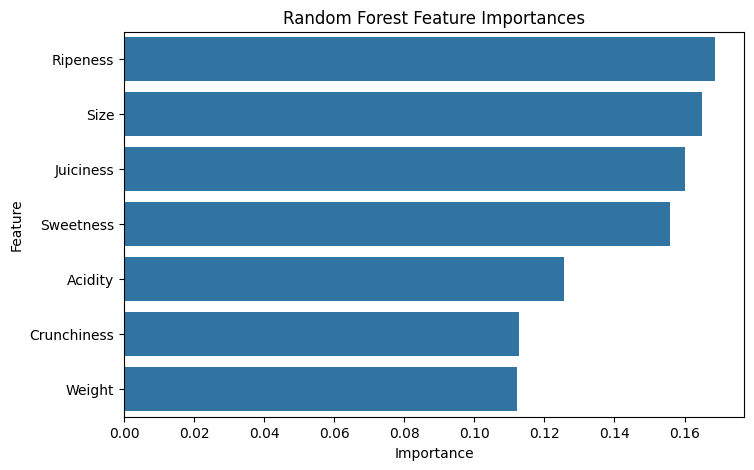

['Size', 'Sweetness']


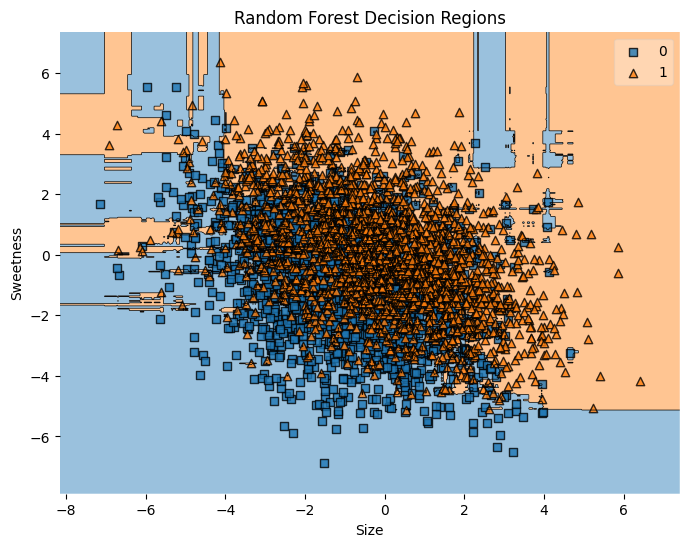

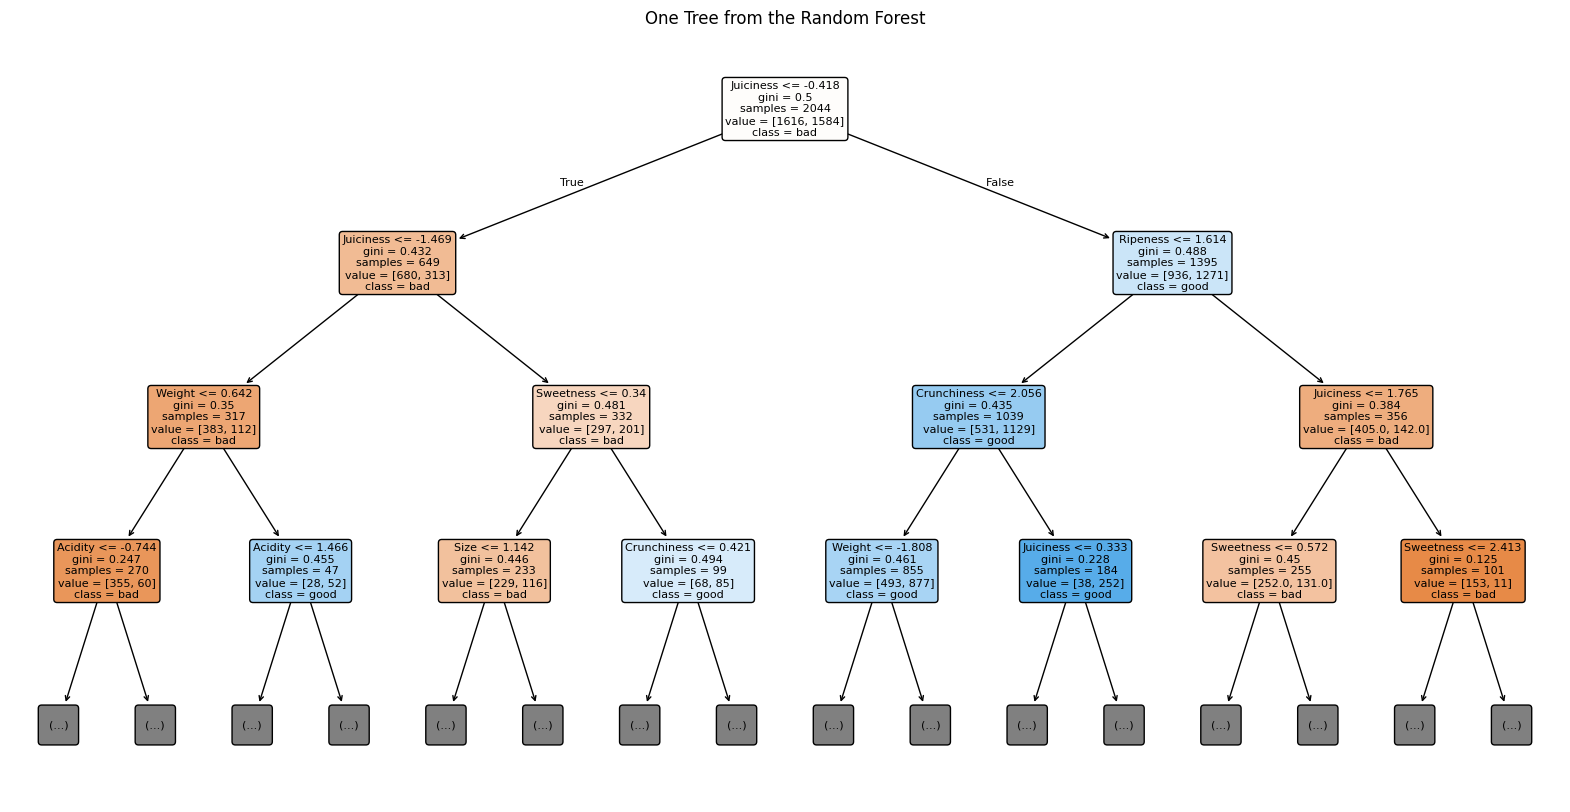

In [58]:
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.ensemble import RandomForestClassifier

X = apples.drop(columns=['Quality'])
y = apples['Quality'].map({'bad': 0, 'good': 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importances, x='importance', y='feature')
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


two_features = tree_two_features(apples, 'Quality')
print(two_features)
X_2 = apples[two_features].to_numpy()
y_2 = apples['Quality'].map({'bad': 0, 'good': 1}).to_numpy()

rf_2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_2.fit(X_2, y_2)

plt.figure(figsize=(8, 6))
plot_decision_regions(X_2, y_2, clf=rf_2)
plt.title('Random Forest Decision Regions')
plt.xlabel(two_features[0])
plt.ylabel(two_features[1])
plt.show()

plt.figure(figsize=(20, 10))
plot_tree(
    rf.estimators_[0],
    feature_names=X.columns,
    class_names=['bad', 'good'],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title('One Tree from the Random Forest')
plt.show()

**Задание 2.3**

Аналогично предыдущему пункту создайте три трехмерных графика (или псевдотрехмерных — двумерных, где цветом отображено третье измерение) для того алгоритма случайного леса с тремя параметрами, который вы получили в 2 пункте задания 2.1.

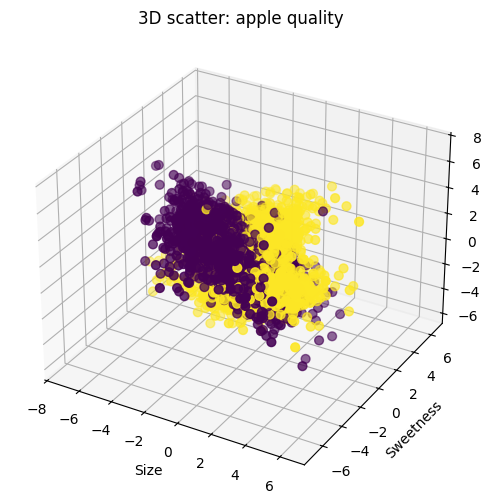

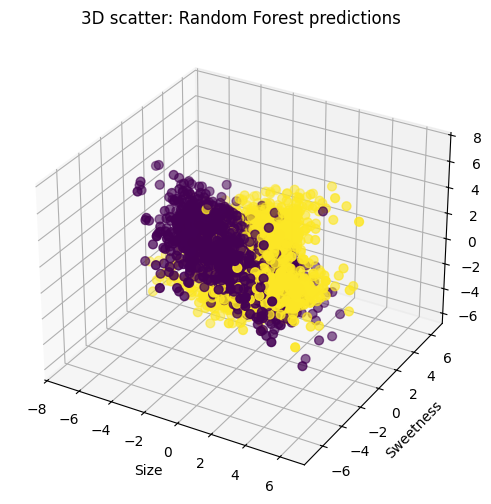

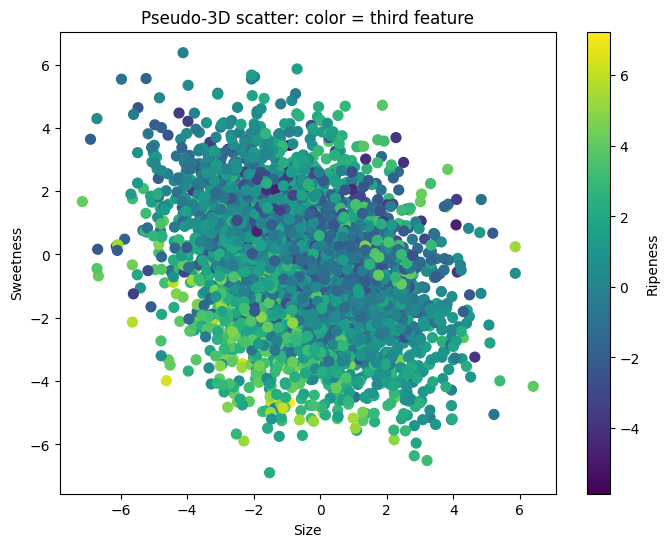

In [59]:
from mpl_toolkits.mplot3d import Axes3D

best_three_features = tree_three_features(apples, 'Quality')

X_3 = apples[best_three_features]
y = apples['Quality'].map({'bad': 0, 'good': 1})

rf_3 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_3.fit(X_3, y)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_3.iloc[:, 0],
    X_3.iloc[:, 1],
    X_3.iloc[:, 2],
    c=y,
    s=40
)

ax.set_title('3D scatter: apple quality')
ax.set_xlabel(best_three_features[0])
ax.set_ylabel(best_three_features[1])
ax.set_zlabel(best_three_features[2])
plt.show()

y_pred = rf_3.predict(X_3)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_3.iloc[:, 0],
    X_3.iloc[:, 1],
    X_3.iloc[:, 2],
    c=y_pred,
    s=40
)

ax.set_title('3D scatter: Random Forest predictions')
ax.set_xlabel(best_three_features[0])
ax.set_ylabel(best_three_features[1])
ax.set_zlabel(best_three_features[2])
plt.show()

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_3.iloc[:, 0],
    X_3.iloc[:, 1],
    c=X_3.iloc[:, 2],
    s=50
)

plt.title('Pseudo-3D scatter: color = third feature')
plt.xlabel(best_three_features[0])
plt.ylabel(best_three_features[1])
plt.colorbar(scatter, label=best_three_features[2])
plt.show()

## Задание 3. Градиентный спуск для функции одной переменной (3 балла)

В рамках занятий мы разбирали создание визуализации алгоритмов градиентного спуска. С нуля напишите свой собственный алгоритм градиентного спуска, создайте визуализацию работы градиентного спуска на каждой итерации для следующей функции:

$$f(x) = x^6 - 3x^4 + 2x^2 + 1$$

Визуализацию снабдите названием, подписями к осям, а также добавьте текст с номером итерации (цвет выбирайте в зависимости от читаемости). Положение точки градиентного спуска на n-ой итерации можно изобразить в качестве `Scatter plot` или `Line plot`.

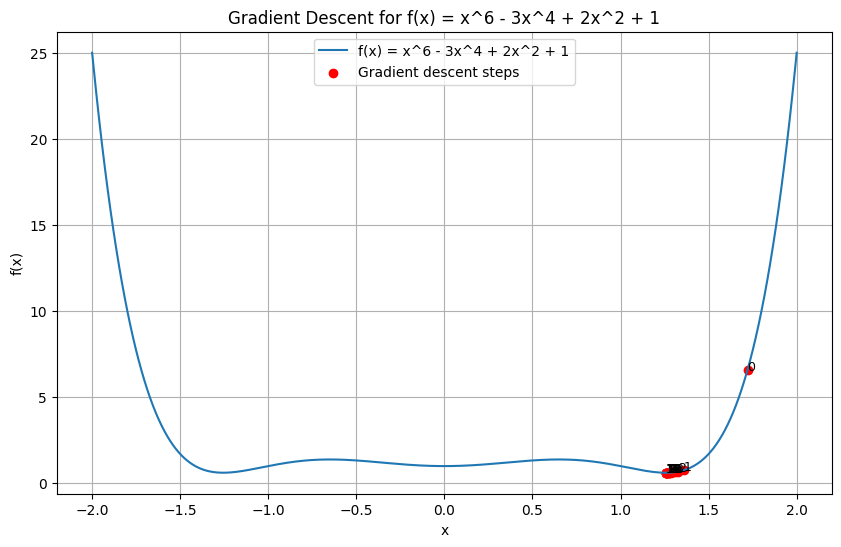

In [91]:
def function(x):
    return x**6 - 3*x**4 + 2*x**2 + 1

def gradient(x):
    return 6*x**5 - 12*x**3 + 4*x

def gradient_descent(x, learning_rate=0.01, num_iterations=100):
    x = np.random.uniform(-2, 2)
    x_history = [x]
    for i in range(num_iterations):
        grad = gradient(x)
        x -= learning_rate * grad
        x_history.append(x)

    return x_history

x_history = gradient_descent(x, learning_rate=0.01, num_iterations=15) # x-координаты шагов градиентного спуска
y_history = [function(x) for x in x_history] # значения функции в этих точках

x_vals = np.linspace(-2, 2, 500) # точки для построения гладкой кривой
y_vals = function(x_vals) # значения функции для этой кривой

plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_vals, label='f(x) = x^6 - 3x^4 + 2x^2 + 1')
plt.scatter(x_history, y_history, color='red', label='Gradient descent steps')

for i, (x, y) in enumerate(zip(x_history, y_history)):
    plt.text(x, y, str(i), fontsize=9, color='black')

plt.title('Gradient Descent for f(x) = x^6 - 3x^4 + 2x^2 + 1')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)
plt.show()

## Задание 4. Визуализация градиентного спуска для трехмерной функции (6 баллов)

В теории оптимизации есть достаточно известная функция — [функция Розенброка](https://en.wikipedia.org/wiki/Rosenbrock_function). Она как раз используется для проверки производительности алгоритмов.
Постройте трехмерную визуализацию (`plt.surface()` или еще лучше ее двумерные аналоги, например, `plt.contourf()`), работы градиентного спуска для функции Розенброка:


$$f(x) = (1 - x_1)^2 + 100(x_2 - x_1^2)^2$$


В качестве визуализации текущего расположения градиентного спуска лучше использовать линейный график красного цвета, чтобы можно было отслеживать блуждания функции в трехмерном пространстве.

Визуализацию снабдите названием, подписями к осям, а также добавьте текст с номером итерации (цвет выбирайте в зависимости от читаемости). Положение точки градиентного спуска на n-ой итерации лучше изобразить через `Line plot`.

Пример работы `plt.contourf()`:

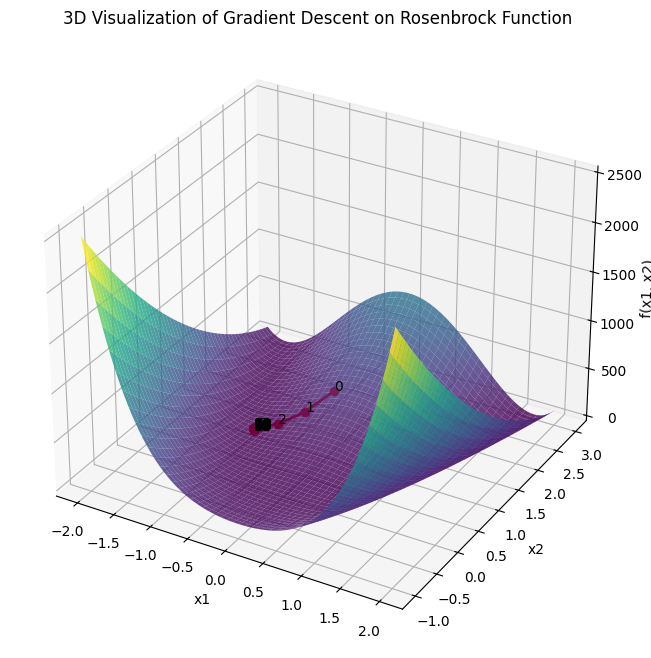

In [114]:
def rosenbrock(x1, x2):
    return (1 - x1)**2 + 100 * (x2 - x1**2)**2

def rosenbrock_gradient(x1, x2):
    df_dx1 = -2 * (1 - x1) - 400 * x1 * (x2 - x1**2)
    df_dx2 = 200 * (x2 - x1**2)
    return np.array([df_dx1, df_dx2])

def rosenbrock_gradient_descent(start, learning_rate=0.001, iterations=50):
    x = np.array(start, dtype=float)
    history = [x.copy()]

    for i in range(iterations):
        grad = rosenbrock_gradient(x[0], x[1])
        x = x - learning_rate * grad
        history.append(x.copy())

    return np.array(history)

history = rosenbrock_gradient_descent(start = np.random.uniform(-2, 2, size=2), learning_rate=0.001, iterations=40)

x1_history = history[:, 0]
x2_history = history[:, 1]
z_history = rosenbrock(x1_history, x2_history)

x1 = np.linspace(-2, 2, 300)
x2 = np.linspace(-1, 3, 300)
X1, X2 = np.meshgrid(x1, x2)
Z = rosenbrock(X1, X2)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X1, X2, Z, cmap='viridis', alpha=0.8)

ax.plot(x1_history, x2_history, z_history, color='red', marker='o', linewidth=2)

for i in range(len(x1_history)):
    ax.text(x1_history[i], x2_history[i], z_history[i], str(i), color='black')

ax.set_title('3D Visualization of Gradient Descent on Rosenbrock Function')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('f(x1, x2)')

plt.show()

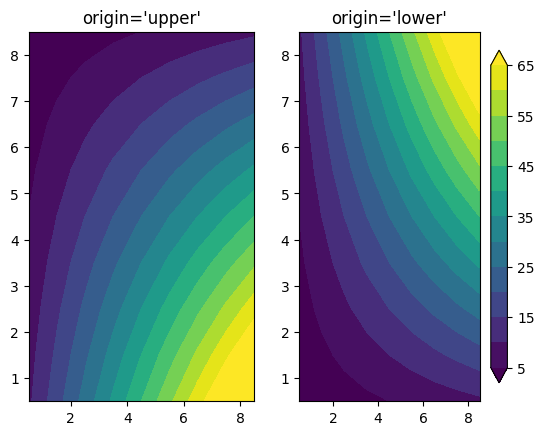

In [82]:
x = np.arange(1, 10)
y = x.reshape(-1, 1)
h = x * y

fig, (ax1, ax2) = plt.subplots(ncols=2)

ax1.set_title("origin='upper'")
ax2.set_title("origin='lower'")
ax1.contourf(h, levels=np.arange(5, 70, 5), extend='both', origin="upper")
cs2 = ax2.contourf(h, levels=np.arange(5, 70, 5), extend='both', origin="lower")
fig.colorbar(cs2, ax=ax2, shrink=0.9)

plt.show()

In [57]:
# Ваш код


**Итоговый балл за домашнее задание = набранный балл / 2**